# what are the most in demand skills for top 3 most popular Data roles?
#### Methodology

1. Clean-up skill column
2. Calculate skill count based on job_title_short
3. calculate skill percentage
4. plot final findings

In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Loading the dataset
df = pd.read_csv('../data_jobs.csv')


# Data Cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

#### Skills Count for India Only

In [2]:
df_india = df[df['job_country'] == 'India'].copy()
df_skills = df_india.explode('job_skills')
df_skills_count = df_skills.groupby(['job_skills','job_title_short']).size()
df_skills_count = df_skills_count.reset_index(name='skill_count')
df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)
df_skills_count

,job_skills,job_title_short,skill_count
1374,sql,Data Engineer,12993
1088,python,Data Engineer,11568
1089,python,Data Scientist,9248
1327,spark,Data Engineer,7157
103,aws,Data Engineer,6993
...,...,...,...
34,angular.js,Data Scientist,1
49,arch,Business Analyst,1
787,mlpack,Data Engineer,1
1679,yarn,Senior Data Scientist,1


#### Top 3 roles

In [3]:
job_titles = df_skills_count['job_title_short'].unique().tolist()
job_titles = sorted(job_titles[:3])
job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

### Ploting

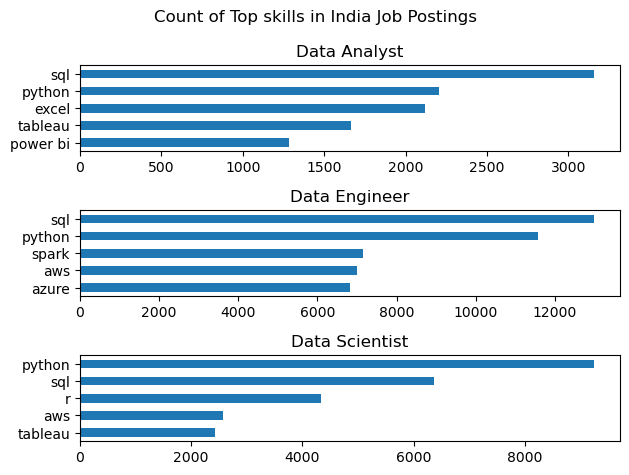

In [4]:
fig, ax =plt.subplots(len(job_titles), 1)

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)
    df_plot.plot(kind='barh', x='job_skills', y='skill_count', ax=ax[i], title =job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)

    fig.tight_layout()
    fig.suptitle('Count of Top skills in India Job Postings')

### Job Title Count For India

In [5]:
df_job_title_count = df_india['job_title_short'].value_counts().reset_index(name = 'jobs_total')

### Merging skills_count  and job_title_count

In [6]:
df_percent = pd.merge(df_skills_count,df_job_title_count, how='left', on='job_title_short')
df_percent

,job_skills,job_title_short,skill_count,jobs_total
0,sql,Data Engineer,12993,19062
1,python,Data Engineer,11568,19062
2,python,Data Scientist,9248,13279
3,spark,Data Engineer,7157,19062
4,aws,Data Engineer,6993,19062
...,...,...,...,...
1684,angular.js,Data Scientist,1,13279
1685,arch,Business Analyst,1,1887
1686,mlpack,Data Engineer,1,19062
1687,yarn,Senior Data Scientist,1,2486


In [7]:
df_percent['skill_percent'] = 100 * df_percent['skill_count'] /df_percent['jobs_total']
df_percent

,job_skills,job_title_short,skill_count,jobs_total,skill_percent
0,sql,Data Engineer,12993,19062,68.161788
1,python,Data Engineer,11568,19062,60.686182
2,python,Data Scientist,9248,13279,69.643798
3,spark,Data Engineer,7157,19062,37.545903
4,aws,Data Engineer,6993,19062,36.685552
...,...,...,...,...,...
1684,angular.js,Data Scientist,1,13279,0.007531
1685,arch,Business Analyst,1,1887,0.052994
1686,mlpack,Data Engineer,1,19062,0.005246
1687,yarn,Senior Data Scientist,1,2486,0.040225


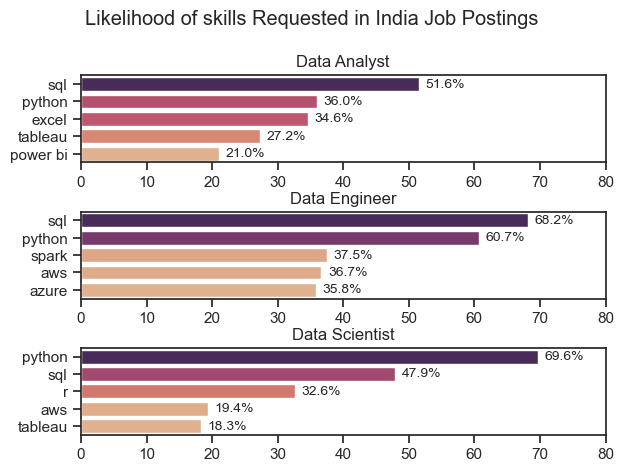

In [22]:
fig, ax =plt.subplots(len(job_titles), 1)
sns.set_theme(style="ticks")

if len(job_titles) == 1:
    ax = [ax]

for i, job_title in enumerate(job_titles):
    df_plot = df_percent[df_percent['job_title_short'] == job_title].head(5)
    
    sns.barplot(data=df_plot, x='skill_percent', y='job_skills', ax=ax[i], hue='skill_count',  palette='flare')
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].set_xlim(0,80)
    ax[i].legend().set_visible(False)

    
    for n, v in enumerate(df_plot['skill_percent']):
        ax[i].text(v + 1, n, f'{v:.1f}%', va='center', fontsize=10)


    fig.suptitle('Likelihood of skills Requested in India Job Postings')
    fig.tight_layout(h_pad=0.1)
